#**Séries temporais do sensor Wide-Field Imager (WFI) para mapeamento de áreas queimadas no Cerrado**

###**Contextualizando as séries temporais [1/5]**

Séries temporais frequentemente revelam padrões que nem sempre são evidentes nos dados brutos. Em cenários de *big data*, o grande volume de dados e a quantidade de variáveis tornam essa análise ainda mais desafiadora. Antes de explorarmos dados geoespaciais, vamos começar com um exemplo simples do cotidiano.

**1) Dados de exemplo**

Em *Data Science*, é comum utilizarmos dados sintéticos: dados artificiais gerados para reproduzir características de situações reais. Eles são úteis para ilustrar conceitos, testar algoritmos e desenvolver modelos sem depender de dados reais (que sempre são custosos de se obter). Como exemplo, considere um pequeno comércio que venda, digamos,  bonés, agasalhos (blusas, suéteres e jaquetas) e camisas da seleção brasileira. A pergunta é simples: **as vendas hipotéticas desses produtos seguem o mesmo comportamento ao longo do tempo?**

Para explorarmos essa questão, vamos definir três padrões de vendas *a priori* (simplificaremos bastante):

a) Bonés: vendas aproximadamente constantes ao longo do ano.

b) Agasalhos: maior demanda durante o inverno (junho a setembro).

c) Camisas da seleção: aumento nas vendas em anos de Copa do Mundo (definiremos os meses de fevereiro a julho do 3º e do 7º ano).

Com essas premissas, podemos gerar três séries temporais sintéticas de vendas mensais ao longo de oito anos (96 meses). Para facilitar a comparação entre os resultados, vamos gerar as séries temporais de bonés e agasalhos com a mesma média anual de vendas (para vermos que mesmo tendo médias semelhantes, esses produtos podem ter padrões diferentes de vendas ao longo de um ano).

In [ ]:
import random
import numpy as np

random.seed(42) # reprodutibilidade

# Gerar dados em listas
bone, agasalho, camisa = [], [], []

for ano in range(1, 9):
    for mes in range(1, 13):
        bone.append(100 + random.randint(-5, 5))

        if mes in [6, 7, 8, 9]:
            agasalho.append(180 + random.randint(-15, 15)) # 6: junho, 7: julho, 8: agosto; 9: setembro
        else:
            agasalho.append(70 + random.randint(-10, 10))

        if ano in [3, 7] and 2 <= mes <= 7:
            camisa.append(260 + random.randint(-20, 20)) # Copas no ano 3 e no ano 7
        else:
            camisa.append(45 + random.randint(-8, 8))

# Estatísticas
print("="*50)
print("ESTATÍSTICAS DESCRITIVAS (96 meses)")
print("="*50)
print(f"Boné:   média={np.mean(bone):.1f}, desvio={np.std(bone):.1f}")
print(f"Agasalho: média={np.mean(agasalho):.1f}, desvio={np.std(agasalho):.1f}")
print(f"Camisa:  média={np.mean(camisa_selecao):.1f}, desvio={np.std(camisa_selecao):.1f}")

ESTATÍSTICAS DESCRITIVAS (96 meses)
Boné:   média=99.7, desvio=3.4
Agasalho: média=107.0, desvio=51.4
Camisa:  média=70.6, desvio=70.0


**2) Visualizando padrões**

Analisar uma sequência de valores diretamente costuma ser pouco intuitivo. Olhe, por exemplo, os primeiros 24 meses das séries temporais nas listas a seguir.

In [25]:
# Visualizando os primeiros 24 elementos das listas criadas anteriormente

print("Primeiros 24 meses:")
print(f"Boné:     {bone[:24]}...")
print(f"Agasalho: {agasalho[:24]}...")
print(f"Camisa:   {camisa[:24]}...")

Primeiros 24 meses:
Boné:     [105, 99, 97, 104, 95, 98, 103, 98, 95, 101, 97, 96, 96, 104, 102, 101, 105, 104, 95, 99, 96, 102, 97, 98]...
Agasalho: [63, 67, 63, 73, 62, 181, 171, 179, 189, 70, 66, 62, 71, 68, 77, 62, 79, 171, 186, 167, 177, 80, 71, 68]...
Camisa:   [37, 44, 39, 38, 43, 37, 50, 45, 42, 45, 47, 49, 48, 38, 40, 46, 48, 39, 44, 44, 45, 48, 48, 39]...


Uma forma mais eficiente de compreender o comportamento de uma série temporal é representá-la graficamente. Nos gráficos a seguir, o eixo y mostra o número de vendas por mês, enquanto o eixo x representa os 96 meses que compõem os oito anos de análise. Assim, padrões como tendências e sazonalidades tornam-se mais fáceis de identificarmos.

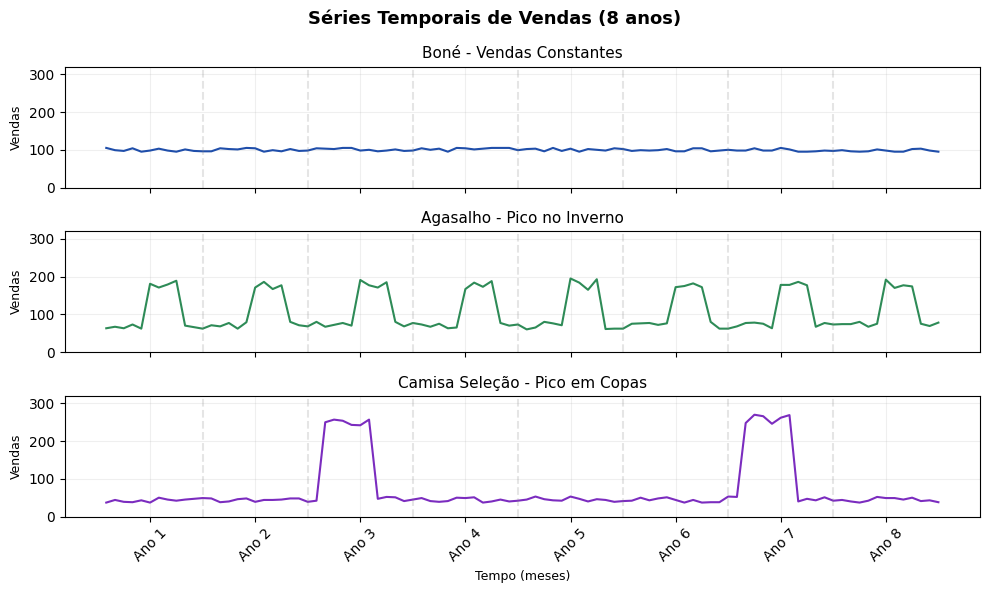

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

produtos = [
    (bone, 'Boné - Vendas Constantes', '#1f4eaa'),
    (agasalho, 'Agasalho - Pico no Inverno', '#2e8b57'),
    (camisa, 'Camisa Seleção - Pico em Copas', '#7b2cbf')
]

for ax, (dados, titulo, cor) in zip(axes, produtos):
    ax.plot(range(1, 97), dados, color=cor, lw=1.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Vendas', fontsize=9)
    ax.set_ylim(0, 320)
    ax.grid(alpha=0.2)
    for ano in range(12, 96, 12):
        ax.axvline(ano, color='gray', ls='--', alpha=0.2)

axes[-1].set_xlabel('Tempo (meses)', fontsize=9)
axes[-1].set_xticks(range(6, 96, 12))
axes[-1].set_xticklabels([f'Ano {i}' for i in range(1, 9)], rotation=45)

plt.suptitle('Séries Temporais de Vendas (8 anos)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Como os dados foram gerados a partir de regras arbitrárias, já temos uma expectativa sobre o comportamento de cada série. Ainda assim, os gráficos tornam esses padrões muito mais fáceis de perceber. Esperamos observar vendas de bonés relativamente estáveis ao longo do tempo, picos anuais nas vendas de agasalhos durante o inverno e aumentos nas vendas de camisas da seleção em anos de Copa do Mundo (um padrão que se repete aproximadamente a cada quatro anos).

3) Podemos ir além dos gráficos anteriores e separar (ou decompor) uma série temporal em seus principais componentes: **tendência**, **sazonalidade** e **resíduo**. Esse processo, conhecido como decomposição de séries temporais, facilita a interpretação dos dados e ajuda a compreender quais fatores explicam as variações observadas ao longo do tempo.

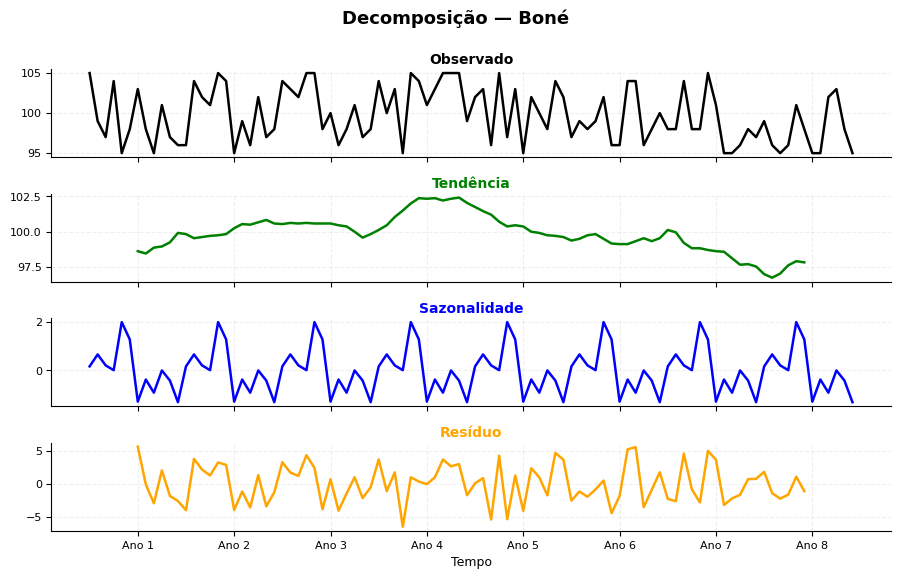

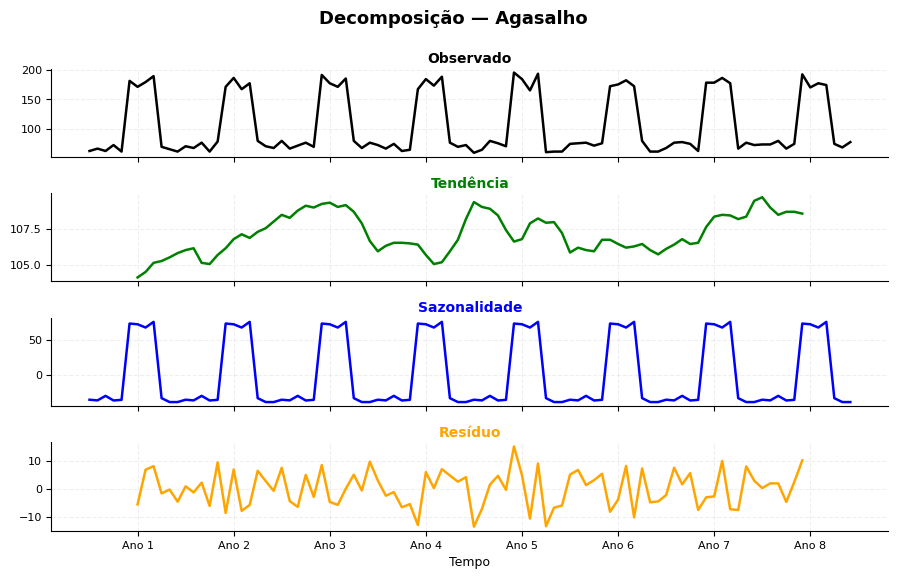

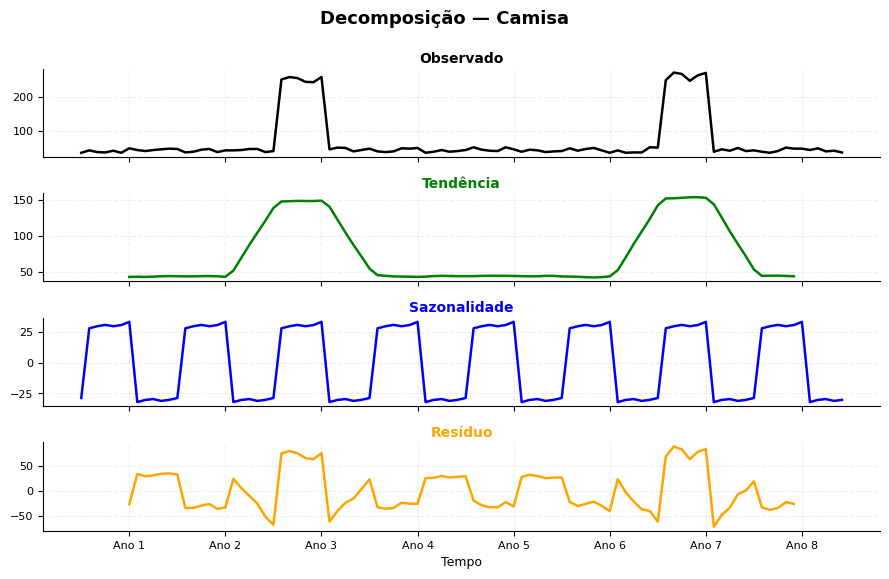

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose # para mais detalhes, consulte: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html
import matplotlib.pyplot as plt

cores = {"Observado": "black", "Tendência": "green",
         "Sazonalidade": "blue", "Resíduo": "orange"}

for nome, dados in [("Boné", bone), ("Agasalho", agasalho), ("Camisa", camisa)]:
    dec = seasonal_decompose(dados, model="additive", period=12) # outra opção de modelo é "multiplicative"; period=12 por se tratar de um ano

    fig, axes = plt.subplots(4, 1, figsize=(9, 5.8), sharex=True)
    componentes = [("Observado", dec.observed), ("Tendência", dec.trend),
                   ("Sazonalidade", dec.seasonal), ("Resíduo", dec.resid)]

    for ax, (titulo, serie) in zip(axes, componentes):
        ax.plot(serie, color=cores[titulo], lw=1.8)
        ax.set_title(titulo, fontsize=10, fontweight="bold", color=cores[titulo], pad=4)
        ax.grid(alpha=0.2, ls="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=8)

    axes[-1].set_xticks(range(6, 96, 12))
    axes[-1].set_xticklabels([f"Ano {i}" for i in range(1, 9)], fontsize=8)
    axes[-1].set_xlabel("Tempo", fontsize=9)

    fig.suptitle(f"Decomposição — {nome}", fontsize=13, fontweight="bold", y=0.99)
    plt.tight_layout()
    plt.show()

A decomposição de uma série temporal consiste em separar a série em componentes que representam diferentes aspectos do seu comportamento. No modelo aditivo (utilizado no exemplo), considera-se que a série é a soma da tendência, da sazonalidade e do resíduo.

**Observado:** corresponde à série temporal original, contendo todas as variações registradas ao longo do tempo.

**Tendência:** representa a evolução de longo prazo da série. No seasonal_decompose(), esse componente é estimado por meio de médias móveis, suavizando as oscilações de curto prazo.

**Sazonalidade:** representa o padrão médio que se repete em intervalos regulares, como meses, trimestres ou estações do ano. Esse componente é estimado após a remoção da tendência.

**Resíduo:** corresponde à parcela da série que permanece após a remoção da tendência e da sazonalidade, reunindo variações não explicadas por esses dois componentes.

**d) Predição**

Daremos um salto e vejamos o passo seguinte: predições. Uma abordagem simples consiste em ajustar uma regressão linear, utilizando o tempo como variável explicativa. Esse modelo captura tendências de crescimento ou declínio e permite estimar, por exemplo, as vendas esperadas de cada produto no ano 9.

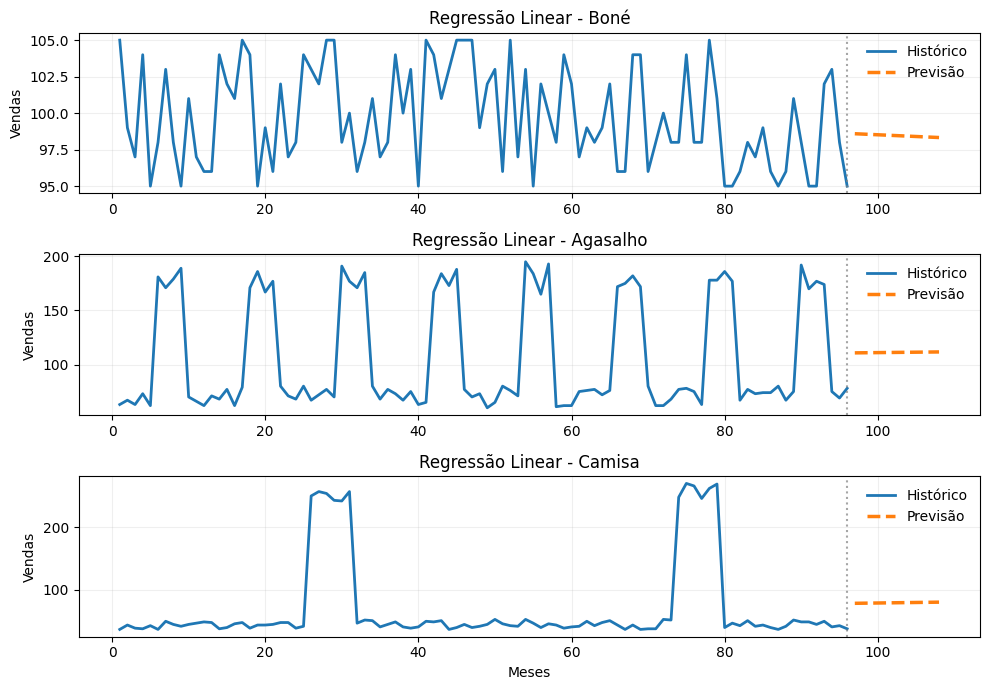

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # para mais detalhes, consulte: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

fig, axes = plt.subplots(3, 1, figsize=(10, 7))

for ax, (nome, dados) in zip(axes, [("Boné", bone), ("Agasalho", agasalho), ("Camisa", camisa)]):
    modelo = LinearRegression().fit(np.arange(96).reshape(-1, 1), dados)
    prev = modelo.predict(np.arange(96, 108).reshape(-1, 1))

    ax.plot(range(1, 97), dados, lw=2, label="Histórico")
    ax.plot(range(97, 109), prev, "--", lw=2.5, label="Previsão")
    ax.axvline(96, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Regressão Linear - {nome}")
    ax.set_ylabel("Vendas")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Meses")
plt.tight_layout()
plt.show()

A regressão linear é uma excelente porta de entrada para previsões em séries temporais, simples, interpretável e eficaz para capturar tendências gerais. Contudo, não considera sazonalidade nem dependências temporais, tratando todos os meses como independentes. Ela funciona bem, digamos, para produtos estáveis (como bonés em nosso exemplo), mas tem desempenho limitado em séries com picos sazonais (como agasalhos no inverno ou camisas em ano de Copa).

O modelo de Holt-Winter, por exemplo, considera as dependências temporais entre os meses e pode identificar alguns padrões recorrentes, como picos de vendas no inverno.

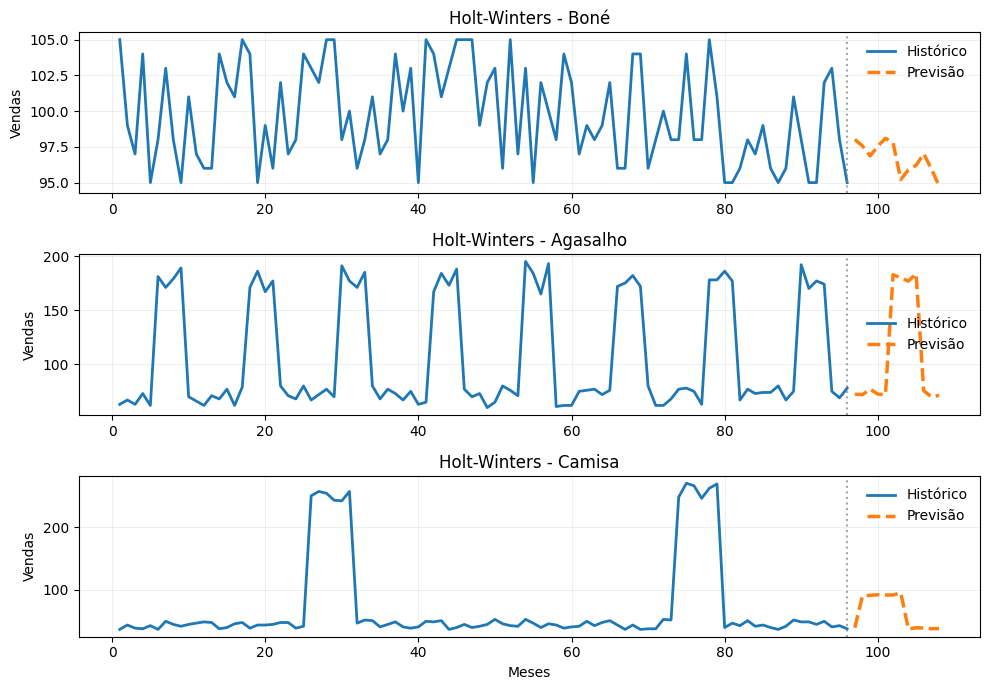

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # para mais detalhes, consulte: https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 7))

for ax, (nome, dados) in zip(axes, [("Boné", bone), ("Agasalho", agasalho), ("Camisa", camisa)]):
    modelo = ExponentialSmoothing(dados, seasonal_periods=12, trend='add', seasonal='add').fit() # seasonal_periodos=12 por se tratar de um ano, mas pode ser alterado
    prev = modelo.forecast(12)

    ax.plot(range(1, 97), dados, lw=2, label="Histórico")
    ax.plot(range(97, 109), prev, "--", lw=2.5, label="Previsão")
    ax.axvline(96, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Holt-Winters - {nome}")
    ax.set_ylabel("Vendas")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Meses")
plt.tight_layout()
plt.show()

O Holt-Winters é adequado para séries temporais com sazonalidade regular, como o agasalho. Nesses casos, o modelo consegue representar os padrões periódicos (intra-anuais) e gerar previsões relativamente coerentes. Para produtos sem sazonalidade, como bonés, o modelo pode introduzir oscilações artificiais, e para ciclos mais longos, como camisas em anos de Copa do Mundo, é necessário ajustar o período sazonal ou utilizar outros modelos (repare que apesar de o 9º ano não ser ano de Copa, o modelo previu um pico de vendas que não é esperado que ocorra).

<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

###**E o que os dados geoespaciais têm a ver com isso?**

Cada produto que analisamos apresenta uma padrão temporal diferente: bonés (estável), agasalhos (sazonalidade anual) e camisas da seleção (ciclos bienais). Agora, transporte essa lógica para o espaço. Uma série temporal de imagens de satélite nada mais é que um empilhamento de observações ao longo do tempo (sequência de bandas espectrais, por exemplo), onde cada pixel carrega sua própria série temporal.

No próximo *script*, vamos aplicar esses conceitos em um caso real: identificar padrões temporais de áreas queimadas no Parque Nacional da Chapada dos Veadeiros, separando os principais componentes temporais do dataset *Wide-Field Imager (WFI) Time Series Dataset for Burned Area Mapping in the Brazilian Cerrado*.

Link para o dataset: https://doi.org/10.57760/sciencedb.14040

**Bio**

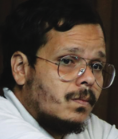

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1